# NHL Playoff Prediction — Data Exploration

This notebook explores regular-season NHL standings data across 15 seasons (2010–11 through 2024–25).

The goal is to get familiar with the shape of the data before moving into predictive analysis — understanding how points are distributed across teams and conferences, which stats move together, and whether anything looks unusual season to season.

**Data source:** NHL Stats API (`api-web.nhle.com/v1`), fetched via `scripts/fetch_data.py` and cleaned via `scripts/preprocess.py`.

**Key stats available per team-season:**
- `points` — total regular season points (2 for a win, 1 for OTL)
- `wins`, `losses`, `ot_losses` — record breakdown
- `goal_diff` — goals for minus goals against
- `points_pct` — points earned as a fraction of maximum possible (points / (GP × 2))
- `goals_for_pg`, `goals_against_pg` — scoring rates per game

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path('..') / 'data' / 'processed'

df = pd.read_csv(PROCESSED_DIR / 'standings_all.csv', dtype={'season': str})
print(f"{df['season'].nunique()} seasons, {len(df)} team-seasons")
df.head()

15 seasons, 462 team-seasons


,season,team,conference,division,games_played,wins,losses,ot_losses,points,goals_for,goals_against,goal_diff,points_pct,goals_for_pg,goals_against_pg,win_pct
0,20102011,VAN,Western,Northwest,82,54,19,9,117,262,185,77,0.713415,3.195122,2.256098,0.658537
1,20102011,WSH,Eastern,Southeast,82,48,23,11,107,224,197,27,0.652439,2.731707,2.402439,0.585366
2,20102011,PHI,Eastern,Atlantic,82,47,23,12,106,259,223,36,0.646341,3.158537,2.719512,0.573171
3,20102011,PIT,Eastern,Atlantic,82,49,25,8,106,238,199,39,0.646341,2.902439,2.426829,0.597561
4,20102011,SJS,Western,Pacific,82,48,25,9,105,248,213,35,0.640244,3.024390,2.597561,0.585366


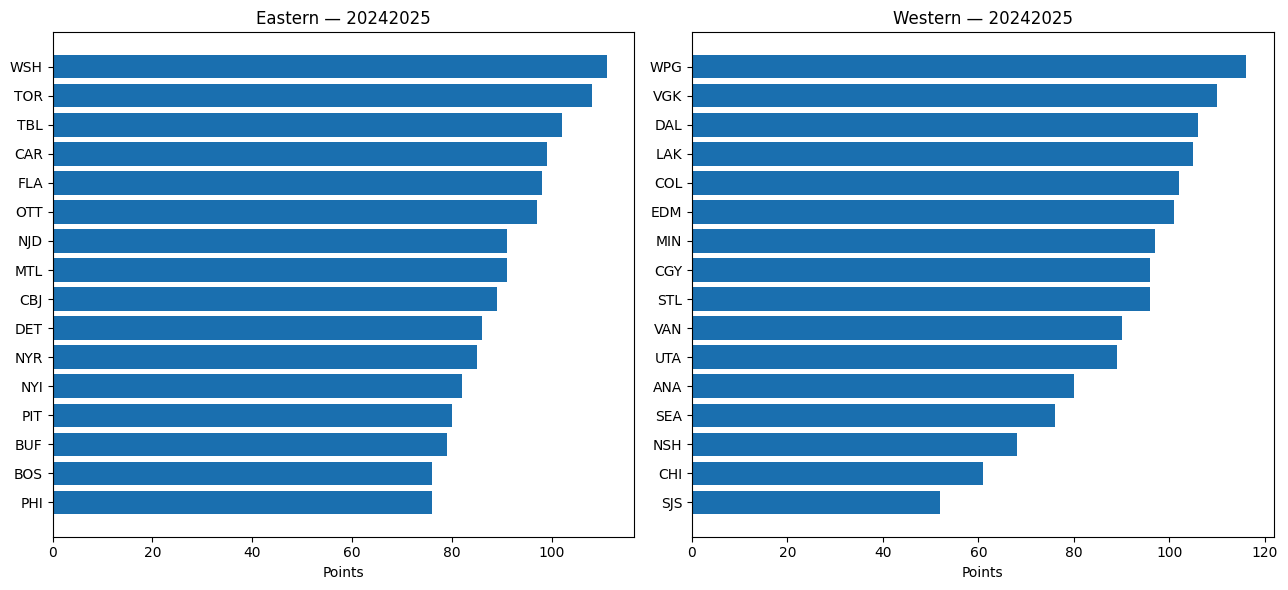

In [2]:
# Points distribution by conference for the most recent season
season = df['season'].max()
season_df = df[df['season'] == season].copy()

conferences = season_df['conference'].dropna().unique()
fig, axes = plt.subplots(1, len(conferences), figsize=(13, 6))
if len(conferences) == 1:
    axes = [axes]

for ax, conf in zip(axes, sorted(conferences)):
    subset = season_df[season_df['conference'] == conf].sort_values('points')
    ax.barh(subset['team'], subset['points'], color='#1a6faf')
    ax.set_title(f'{conf} — {season}')
    ax.set_xlabel('Points')

plt.tight_layout()
plt.show()

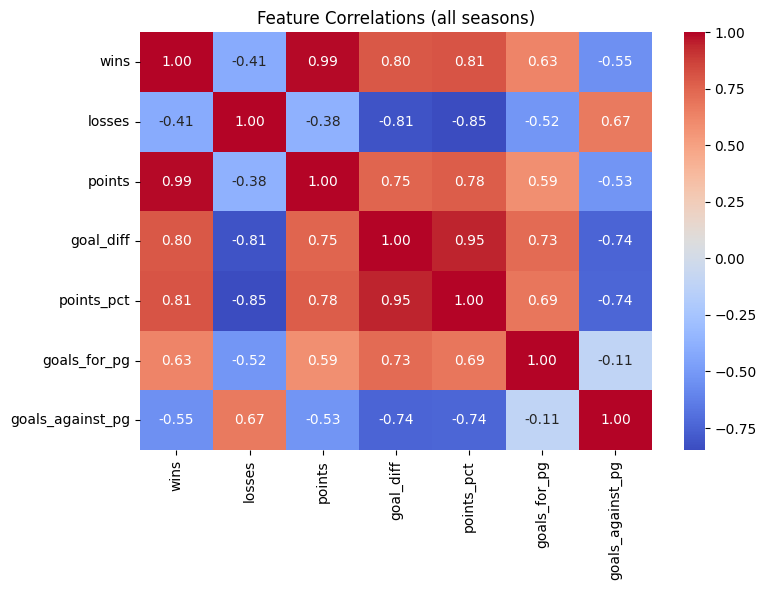

In [3]:
# Correlation heatmap across all seasons
numeric = df[['wins', 'losses', 'points', 'goal_diff', 'points_pct', 'goals_for_pg', 'goals_against_pg']]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlations (all seasons)')
plt.tight_layout()
plt.show()

C:\Users\style\AppData\Local\Temp\ipykernel_37364\2790758193.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_season, labels=seasons_sorted)


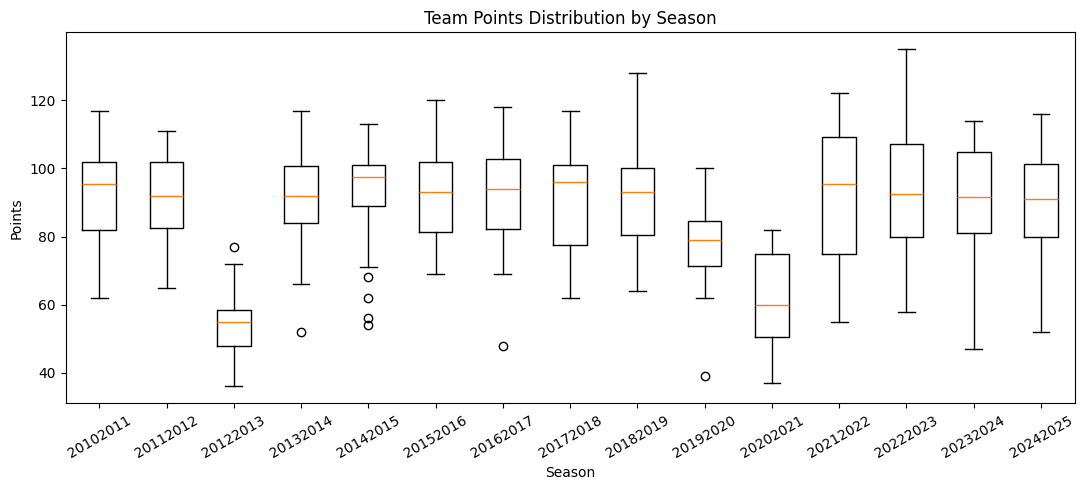

In [4]:
# Points distribution across all seasons (box plot per season)
fig, ax = plt.subplots(figsize=(11, 5))
seasons_sorted = sorted(df['season'].unique())
data_by_season = [df[df['season'] == s]['points'].values for s in seasons_sorted]
ax.boxplot(data_by_season, labels=seasons_sorted)
ax.set_xlabel('Season')
ax.set_ylabel('Points')
ax.set_title('Team Points Distribution by Season')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()